# Architecture of filters

So, the english is not very good, I will improve that

In [65]:
import itertools

import sympy as sy
import numpy as np

In [66]:
import fitz

from utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution

In [67]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [68]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

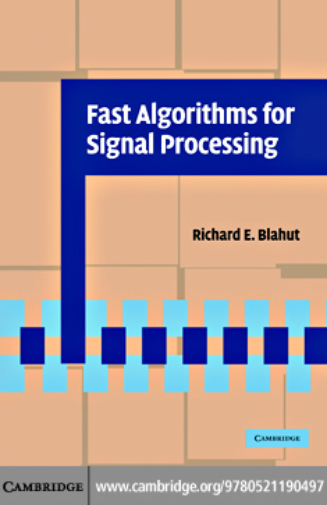

In [69]:
plot_pdf(doc[0], dpi=100)

## Polynomials

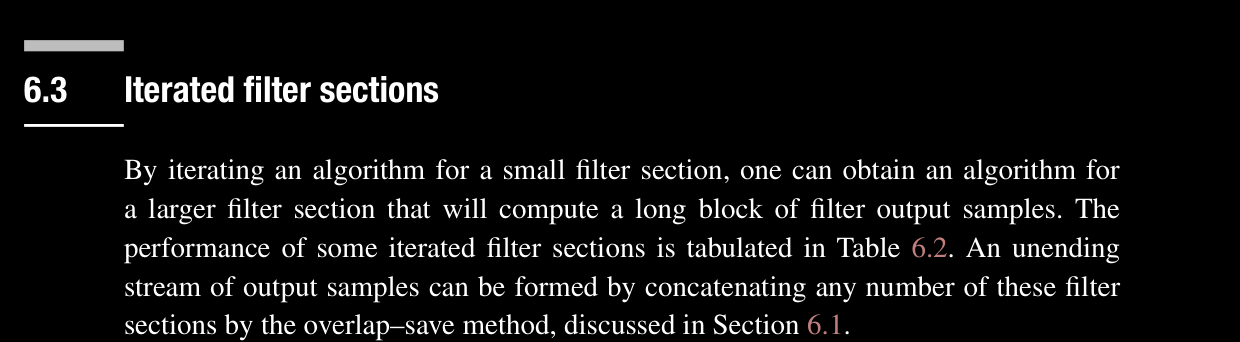

In [70]:
plot_pdf(doc[217], [.6, .78])

Size of vectors

In [71]:
v_size = 2

Example of vectors for the convolution

In [72]:
d_values = list(range(1, v_size+1))
g_values = list(range(1, v_size+1))
print(d_values, g_values)

[1, 2] [1, 2]


Polynomial degree

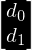

In [73]:
d0 = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(v_size))))
d0

In [74]:
g0 = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(v_size))))
g0

Just defining values of matrices

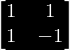

In [75]:
win = sy.Matrix([[1, 1], [1, -1]])
win

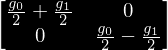

In [76]:
bg0 = sy.diag(*(win*g0*1/2).tolist())
bg0

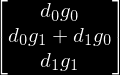

In [77]:
sy.Matrix(np.convolve(np.array(d0).reshape(-1), np.array(g0).reshape(-1)))

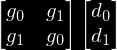

In [78]:
sy.MatMul(win * bg0 * win, d0)

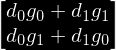

In [79]:
sy.MatMul(win, bg0, win, d0, evaluate=True)

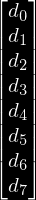

In [254]:
d2 = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(v_size*4))))
d2

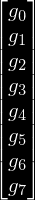

In [255]:
g2 = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(v_size*4))))
g2

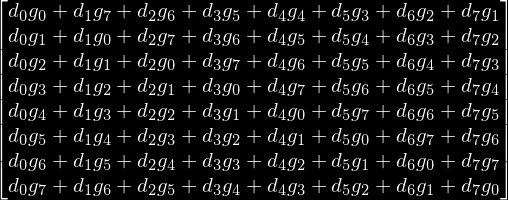

In [256]:
cc2 = sy.Matrix(symmetrical_cyclic_convolution(np.array(d2).reshape(-1), np.array(g2).reshape(-1)))
cc2

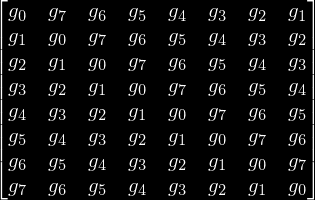

In [257]:
cc2_args = [[arg for mul in line.args for arg in mul.args if 'g' in arg.name] for line in cc2]
sy.Matrix(cc2_args)

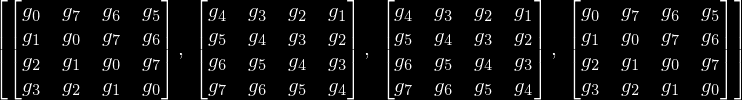

In [258]:
cc2_args = np.array(cc2_args)
g2m = [sy.Matrix(cc2_args[r:r+4, c:c+4].tolist()) for r in range(0, cc2_args.shape[0], 4) for c in range(0, cc2_args.shape[1], 4)]
g2m

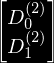

In [173]:
dd2 = sy.Matrix(sy.symbols(" ".join(f"D^(2)_{i}"for i in range(2))))
dd2

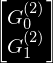

In [172]:
gg2 = sy.Matrix(sy.symbols(" ".join(f"G^(2)_{i}"for i in range(2))))
gg2

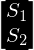

In [86]:
ss1 = sy.Matrix(sy.symbols(" ".join(f"S_{i}"for i in range(1, 3))))
ss1

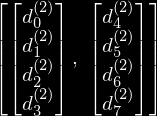

In [221]:
d2m = [
    sy.Matrix(d2[0:4]),
    sy.Matrix(d2[4:8])
]
d2m

In [93]:
ii = sy.symbols('I')
ii

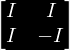

In [94]:
win_ii = sy.Matrix([
    [ii, ii], 
    [ii, -ii]
])
win_ii

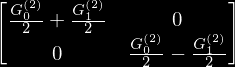

In [222]:
gg2m = sy.diag(*[
    gg2[0] + gg2[1], 
    gg2[0] - gg2[1]
])* 1/2
gg2m

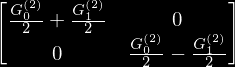

In [232]:
sy.diag(*(win * gg2/2).flat())

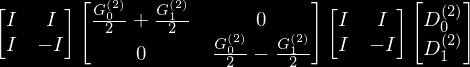

In [233]:
sy.MatMul(win_ii, gg2m, win_ii, dd2)

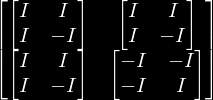

In [158]:
win_ii2 = win_ii.subs({ii: win_ii})
win_ii2

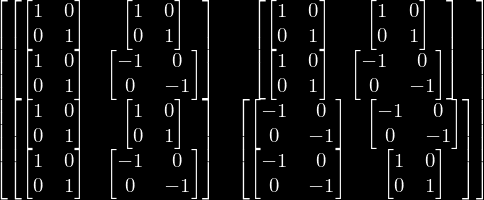

In [159]:
win_ii2.subs({ii: sy.eye(2)})

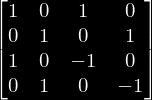

In [260]:
win1 = sy.Matrix([
    [sy.eye(2), sy.eye(2)], 
    [sy.eye(2), -sy.eye(2)]
])
win1

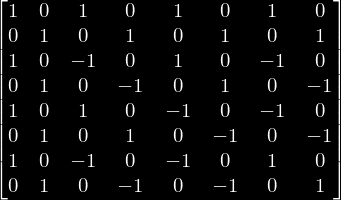

In [263]:
win2 = sy.Matrix([
    [win1, win1], 
    [win1, -win1]
])
win2

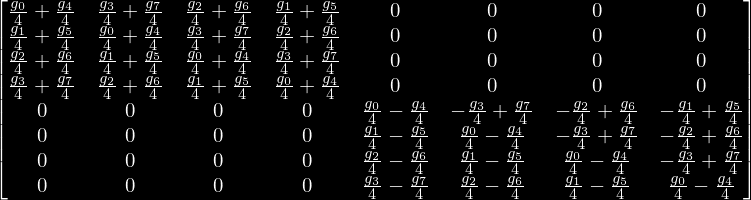

In [267]:
bg2 = sy.diag(*[
    g2m[0] + g2m[1], 
    g2m[0] - g2m[1]
])/4
bg2

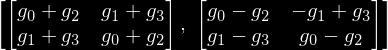

In [101]:
[g1m[0]*win[0,0] + g1m[1]*win[0,1], g1m[0]*win[0,1] + g1m[1]*win[1,1]]

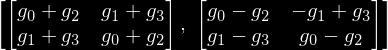

In [102]:
[(g1m[0]*win[r, 0] + g1m[1]*win[r, 1]) for r in range(2)]

In [103]:
g1m[0][0, :] + g1m[1][0, :]

In [104]:
g1m[0][0, :] - g1m[1][0, :]

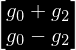

In [105]:
win * sy.Matrix([
    g1[0], g1[2]
])

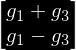

In [106]:
win * sy.Matrix([
    g1[1], g1[3]
])

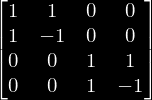

In [107]:
win1g = sy.diag(*[win, win])
win1g

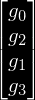

In [108]:
g1_kr = sy.Matrix([g1[0], g1[2], g1[1], g1[3]])
g1_kr

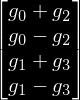

In [109]:
win1g * g1_kr

A organização dessa tabela está um pouco confusa ainda mas é igual as tabelas $m1$ e $m2$ das variáveis $x'$, página 3 coluna 1, de Diaz-Perez

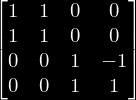

In [110]:
win1g2 = sy.Matrix([
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [0, 0, 1, -1],
    [0, 0, 1, 1],
])
win1g2

Não funcionou, mas sem problema por enquanto pegamos os resultados e reorganizamos na nova matriz

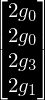

In [111]:
win1g2 * win1g * g1_kr

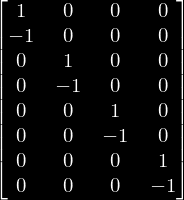

In [112]:
win1g2 = sy.Matrix([
    [1, 0, 0, 0],
    [-1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, -1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, -1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, -1],

])
win1g2

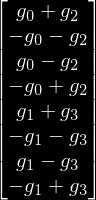

In [113]:
win1g2 * win1g * g1_kr

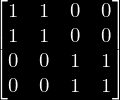

In [114]:
eye01_interpolated = sy.Matrix([
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [0, 0, 1, 1],
    [0, 0, 1, 1]
])
eye01_interpolated

4 multipliações apenas, uma delas com uma inversão

fazer uma matriz vertical com as somas de g e uma matriz quase identidade com as multiplicações de g

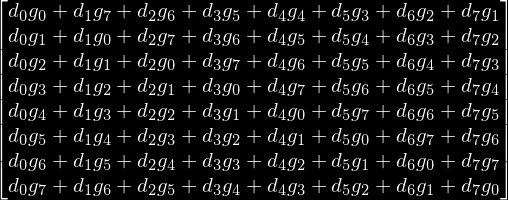

In [269]:
cc = sy.Matrix(symmetrical_cyclic_convolution(np.array(d2).reshape(-1), np.array(g2).reshape(-1)))
cc

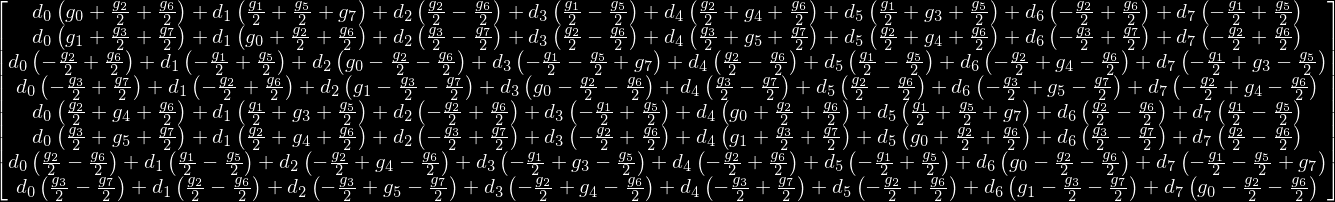

In [270]:
ssx = sy.MatMul(win2, bg2, win2, d2, evaluate=True)
ssx

In [243]:
np.all(np.array(cc) == np.array(ssx))

False

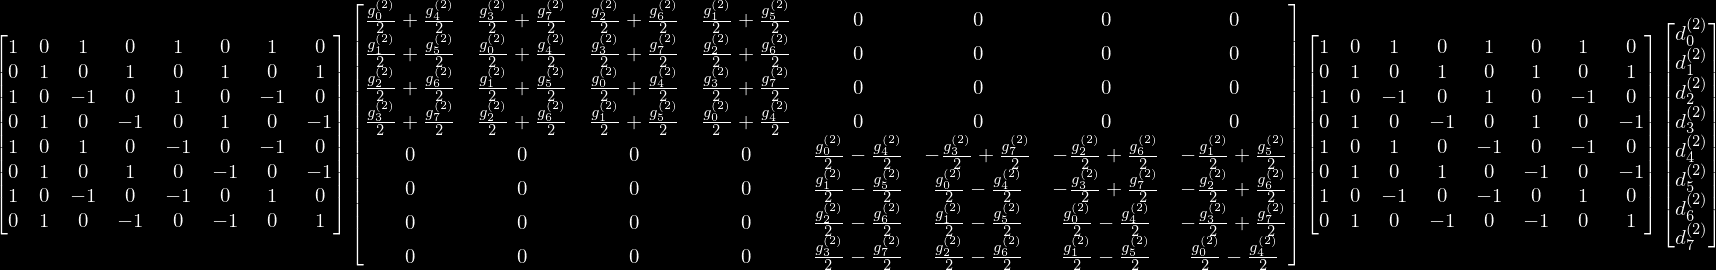

In [244]:
ssx = sy.MatMul(win2, bg2, win2, d2)
ssx

In [271]:
subs = {k: v for k, v in zip(g2.flat(), range(0, len(g2.flat())))}
subs

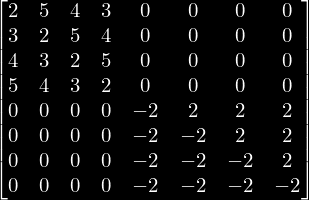

In [246]:
bg2_subs = bg2.subs(subs)
bg2_subs

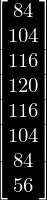

In [248]:
sy.Matrix(symmetrical_cyclic_convolution(range(len(d2.flat())), range(len(g2.flat()))))

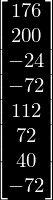

In [251]:
r = win2 * bg2_subs * win2 * sy.Matrix(list(range(len(d2.flat()))))
r

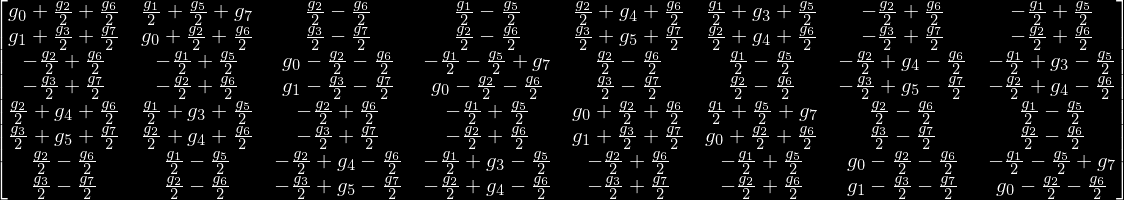

In [268]:
win2 * bg2 * win2